Non-linear regression models relationships where the target variable
is a non-linear function of the parameters.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Sigmoid function
def sigmoid(x, a, b):
    return 1 / (1 + np.exp(-a * (x - b)))

# Generate data
x_data = np.linspace(0, 10, 100)
y_data = sigmoid(x_data, 2, 5) + np.random.normal(scale=0.05, size=x_data.shape)

# Fit model
popt, _ = curve_fit(sigmoid, x_data, y_data)
a_fit, b_fit = popt

# Predict
y_fit = sigmoid(x_data, a_fit, b_fit)
print(y_fit)

[8.26866098e-05 9.98926665e-05 1.20678658e-04 1.45789235e-04
 1.76123851e-04 2.12768901e-04 2.57036508e-04 3.10511347e-04
 3.75107118e-04 4.53134676e-04 5.47384176e-04 6.61224081e-04
 7.98720437e-04 9.64780479e-04 1.16532540e-03 1.40749803e-03
 1.69991223e-03 2.05295192e-03 2.47912923e-03 2.99351233e-03
 3.61423573e-03 4.36310671e-03 5.26632392e-03 6.35532478e-03
 7.66777968e-03 9.24875031e-03 1.11520279e-02 1.34416624e-02
 1.61936859e-02 1.94980183e-02 2.34605234e-02 2.82051478e-02
 3.38760320e-02 4.06394146e-02 4.86850677e-02 5.82268962e-02
 6.95022073e-02 8.27690279e-02 9.83007324e-02 1.16377186e-01
 1.37271661e-01 1.61233036e-01 1.88463294e-01 2.19091155e-01
 2.53143840e-01 2.90520195e-01 3.30969564e-01 3.74081302e-01
 4.19289309e-01 4.65894115e-01 5.13102022e-01 5.60077328e-01
 6.06000626e-01 6.50124727e-01 6.91820326e-01 7.30605957e-01
 7.66160182e-01 7.98317342e-01 8.27050560e-01 8.52446841e-01
 8.74678959e-01 8.93977943e-01 9.10608687e-01 9.24850008e-01
 9.36979502e-01 9.472628

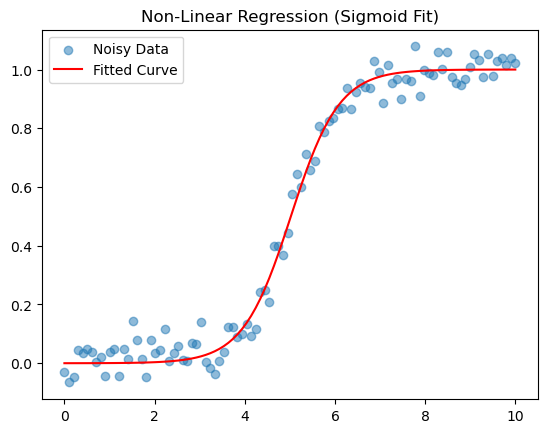

In [3]:
# Plot
plt.scatter(x_data, y_data, label='Noisy Data', alpha=0.5)
plt.plot(x_data, y_fit, color='red', label='Fitted Curve')
plt.title("Non-Linear Regression (Sigmoid Fit)")
plt.legend()
plt.show()

# Maximum Likelihood Estimation for Regression
MLE estimates the parameters that maximize the likelihood of observing the data under a probabilistic model.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Generate data
np.random.seed(0)
X = np.random.rand(100, 1)
y = 3 * X.squeeze() + 2 + np.random.randn(100) * 0.5

# Add intercept
X_b = np.c_[np.ones((100, 1)), X]

# Log-likelihood function for linear regression
def neg_log_likelihood(theta):
    y_pred = X_b @ theta
    residuals = y - y_pred
    sigma2 = np.var(residuals)
    n = len(y)
    return 0.5 * n * np.log(2 * np.pi * sigma2) + (0.5 / sigma2) * np.sum(residuals**2)

# Minimize the negative log-likelihood
result = minimize(neg_log_likelihood, np.zeros(X_b.shape[1]))
theta_mle = result.x
print("Estimated coefficients (MLE):", theta_mle)

Estimated coefficients (MLE): [2.11107553 2.96846752]
